In [9]:
import numpy as np
import scipy.sparse as sm
import numpy.linalg as la
import scipy.sparse.linalg as sml
import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

In [30]:
def Mat_AB(x,r):
    N = len(x)-2
    A , B = np.zeros((N,N)) , np.zeros((N,N))
    d_A , d_B = 2*(1+r) , 2*(1-r)
    for i in range(N-1):
        A[i,i] , B[i,i] = d_A , d_B
        A[i,i+1] , B[i,i+1] = -r , r
        A[i+1,i] , B[i+1,i] = -r , r
    A[-1,-1] , B[-1,-1] = d_A , d_B
    return A , B

def Met_CN_s(x,t,Psi0,D=0.5):
    r = (D*(t[1]-t[0]))/((x[1]-x[0])**2)
    sol = np.zeros( (len(x),len(t)) )
    sol[:,0] = Psi0
    #print('Valor r=',r)
    if r < 1:
        A , B = Mat_AB(x,r)
        A , B = sm.csc_matrix(A) , sm.csc_matrix(B)
        A_inv = sml.inv(A)
        M_evol = A_inv@B
        for i in range(len(t)-1):
            # Solo evolucionar los puntos interiores
            sol[1:-1,i+1] = M_evol@sol[1:-1,i]
    else:
        print('No hay convergencia')
    return sol

def Met_CN(x,t,Psi0,D=0.5):
    r = (D*(t[1]-t[0]))/((x[1]-x[0])**2)
    sol = np.zeros( (len(x),len(t)) )
    sol[:,0] = Psi0
    #print('Valor r=',r)
    if r < 1:
        A , B = Mat_AB(x,r)
        A_inv = la.inv(A)
        M_evol = np.dot(A_inv,B)
        for i in range(len(t)-1):
            # Solo evolucionar los puntos interiores
            sol[1:-1,i+1] = np.dot(M_evol,sol[1:-1,i])
    else:
        print('No hay convergencia')
    return sol

In [46]:
x , t = np.linspace(0,1,100) , np.linspace(0,1,5000)
P0 = -x*(x-1)

In [47]:
%%timeit
sol_Psi_sparse = Met_CN_s(x,t,P0)

49.2 ms ± 524 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


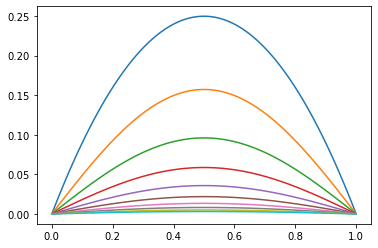

In [48]:
sol_Psi_sparse = Met_CN_s(x,t,P0)
for i in range(1,5000,500):
    plt.plot(x,sol_Psi_sparse[:,i])
plt.show()

In [49]:
%%timeit
sol_Psi = Met_CN(x,t,P0)

51.8 ms ± 7.43 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


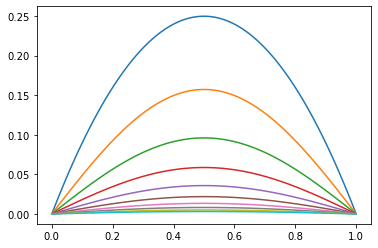

In [50]:
sol_Psi = Met_CN(x,t,P0)
for i in range(1,5000,500):
    plt.plot(x,sol_Psi[:,i])
plt.show()